# California Housing Assignment

Complete notebook for Questions 1–10.

**Dataset:** California Housing (`housing.csv`) with columns:
`longitude, latitude, housing_median_age, total_rooms, total_bedrooms, population, households, median_income, median_house_value, ocean_proximity`

Place the downloaded `housing.csv` in the same folder as this notebook before running.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    StratifiedShuffleSplit,
    cross_val_score,
    GridSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option("display.max_columns", None)


## Load dataset

In [4]:
housing = pd.read_csv("housing.csv")

print("Dataset shape:", housing.shape)
display(housing.head())
print("\nMissing values:")
display(housing.isnull().sum())


Dataset shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



Missing values:


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

## Q1 — `income_cat` and stratified train/test split

In [5]:
housing["income_cat"] = pd.cut(
    housing["median_income"],
    bins=[0, 1.5, 3.0, 4.5, 6.0, np.inf],
    labels=[1, 2, 3, 4, 5]
)

print("Overall counts:")
display(housing["income_cat"].value_counts().sort_index())

split = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

for train_idx, test_idx in split.split(housing, housing["income_cat"]):
    train_set_full = housing.iloc[train_idx].copy()
    test_set_full = housing.iloc[test_idx].copy()

print("Train income_cat counts:")
display(train_set_full["income_cat"].value_counts().sort_index())

print("Test income_cat counts:")
display(test_set_full["income_cat"].value_counts().sort_index())

# Save the counts for the final summary
train_income_counts = train_set_full["income_cat"].value_counts().sort_index()
test_income_counts = test_set_full["income_cat"].value_counts().sort_index()

# Remove income_cat after stratification
train_set = train_set_full.drop("income_cat", axis=1)
test_set = test_set_full.drop("income_cat", axis=1)

print("Train shape:", train_set.shape)
print("Test shape:", test_set.shape)


Overall counts:


income_cat
1     822
2    6581
3    7236
4    3639
5    2362
Name: count, dtype: int64

Train income_cat counts:


income_cat
1     657
2    5265
3    5789
4    2911
5    1890
Name: count, dtype: int64

Test income_cat counts:


income_cat
1     165
2    1316
3    1447
4     728
5     472
Name: count, dtype: int64

Train shape: (16512, 10)
Test shape: (4128, 10)


## Q2 — `ColumnTransformer`

Numeric pipeline:

`SimpleImputer(strategy="median") → StandardScaler()`

Categorical pipeline:

`OneHotEncoder(handle_unknown="ignore")` on `ocean_proximity`.


In [6]:
X_train = train_set.drop("median_house_value", axis=1)
y_train = train_set["median_house_value"]

X_test = test_set.drop("median_house_value", axis=1)
y_test = test_set["median_house_value"]

numeric_features = [
    "longitude", "latitude", "housing_median_age",
    "total_rooms", "total_bedrooms", "population",
    "households", "median_income"
]

categorical_features = ["ocean_proximity"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

X_train_prepared = preprocessor.fit_transform(X_train)

print("Transformed training shape:", X_train_prepared.shape)
print("Feature names:")
print(preprocessor.get_feature_names_out())


Transformed training shape: (16512, 13)
Feature names:
['num__longitude' 'num__latitude' 'num__housing_median_age'
 'num__total_rooms' 'num__total_bedrooms' 'num__population'
 'num__households' 'num__median_income' 'cat__ocean_proximity_<1H OCEAN'
 'cat__ocean_proximity_INLAND' 'cat__ocean_proximity_ISLAND'
 'cat__ocean_proximity_NEAR BAY' 'cat__ocean_proximity_NEAR OCEAN']


## Q3 — 5-fold CV: Linear Regression, Decision Tree, Random Forest

In [7]:
lin_reg = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

tree_reg = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

forest_reg = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

def evaluate_model(model, name):
    scores = -cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    print(f"{name}: {scores.mean():,.2f} ± {scores.std():,.2f} RMSE")
    return scores

lin_scores = evaluate_model(lin_reg, "Linear Regression")
tree_scores = evaluate_model(tree_reg, "Decision Tree")
forest_scores = evaluate_model(forest_reg, "Random Forest")


Linear Regression: 69,218.40 ± 689.40 RMSE
Decision Tree: 70,676.23 ± 1,522.71 RMSE
Random Forest: 49,941.18 ± 778.72 RMSE


## Q4 — GridSearchCV for Random Forest

In [8]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_features": [2, 4, 6, 8]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best CV RMSE: {-grid_search.best_score_:,.2f}")

grid_results = pd.DataFrame(grid_search.cv_results_)
grid_results["RMSE"] = -grid_results["mean_test_score"]

display(
    grid_results[
        ["param_model__n_estimators",
         "param_model__max_features",
         "RMSE",
         "rank_test_score"]
    ].sort_values("RMSE")
)


Best parameters: {'model__max_features': 8, 'model__n_estimators': 200}
Best CV RMSE: 49,081.70


,param_model__n_estimators,param_model__max_features,RMSE,rank_test_score
11,200,8,49081.704423,1
8,200,6,49210.282458,2
10,100,8,49229.898986,3
7,100,6,49414.766541,4
5,200,4,49434.382218,5
9,50,8,49507.503542,6
4,100,4,49614.382553,7
6,50,6,49712.126707,8
3,50,4,49873.902911,9
2,200,2,51232.142051,10


## Q5 — Test RMSE, MAE and R²

In [9]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_mae = mean_absolute_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: {test_rmse:,.2f}")
print(f"Test MAE : {test_mae:,.2f}")
print(f"Test R²  : {test_r2:.4f}")


Test RMSE: 46,563.78
Test MAE : 30,805.89
Test R²  : 0.8336


## Q6 — NumPy Normal Equation

Using only:

- `median_income`
- `housing_median_age`

with an intercept term.

\[
\theta=(X^TX)^{-1}X^Ty
\]


In [10]:
X_two = housing[[
    "median_income",
    "housing_median_age"
]].values.astype(float)

y_two = housing["median_house_value"].values.astype(float)

# Bias/intercept column
X_bias = np.c_[np.ones(X_two.shape[0]), X_two]

# Requested Normal Equation
theta_numpy = (
    np.linalg.inv(X_bias.T @ X_bias)
    @ X_bias.T
    @ y_two
)

# sklearn on exactly the same two features
sk_model = LinearRegression()
sk_model.fit(X_two, y_two)

theta_sklearn = np.array([
    sk_model.intercept_,
    sk_model.coef_[0],
    sk_model.coef_[1]
])

percent_difference = (
    np.abs(theta_numpy - theta_sklearn)
    / np.abs(theta_sklearn)
) * 100

comparison = pd.DataFrame({
    "Parameter": [
        "Intercept",
        "median_income",
        "housing_median_age"
    ],
    "NumPy": theta_numpy,
    "Sklearn": theta_sklearn,
    "% Difference": percent_difference
})

display(comparison)


,Parameter,NumPy,Sklearn,% Difference
0,Intercept,-10189.032759,-10189.032759,8.926212e-14
1,median_income,43169.190754,43169.190754,5.056354e-14
2,housing_median_age,1744.134446,1744.134446,3.780578e-13


## Q7 — Geographic scatter plot

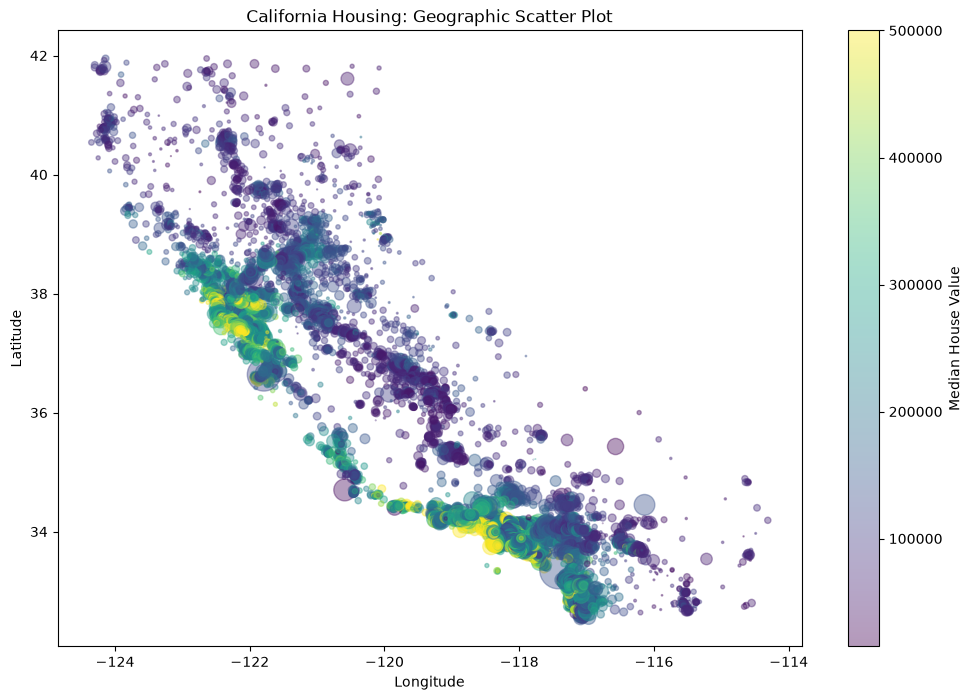

In [11]:
plt.figure(figsize=(12, 8))

plt.scatter(
    housing["longitude"],
    housing["latitude"],
    s=housing["population"] / 50,
    c=housing["median_house_value"],
    alpha=0.4
)

plt.colorbar(label="Median House Value")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("California Housing: Geographic Scatter Plot")
plt.show()


## Q8 — Histogram of median house value

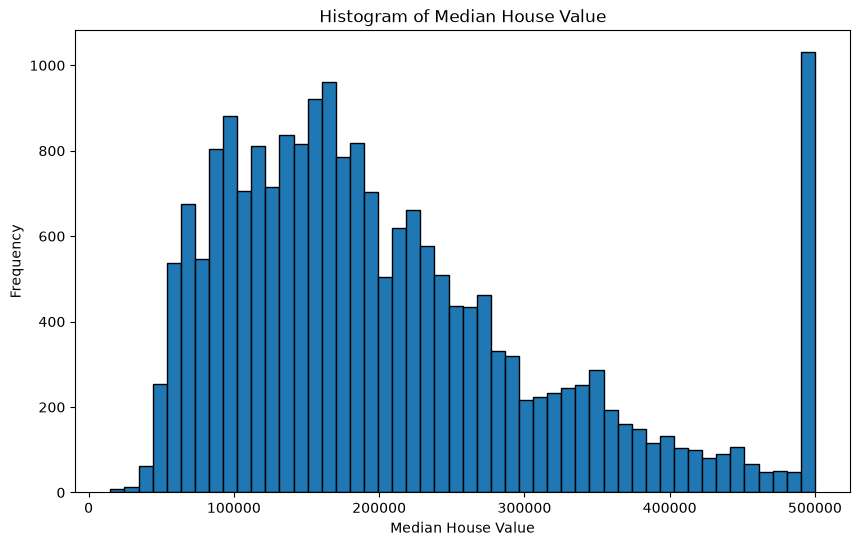

In [12]:
plt.figure(figsize=(10, 6))

plt.hist(
    housing["median_house_value"],
    bins=50,
    edgecolor="black"
)

plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.title("Histogram of Median House Value")
plt.show()


## Q9 — Predicted vs actual

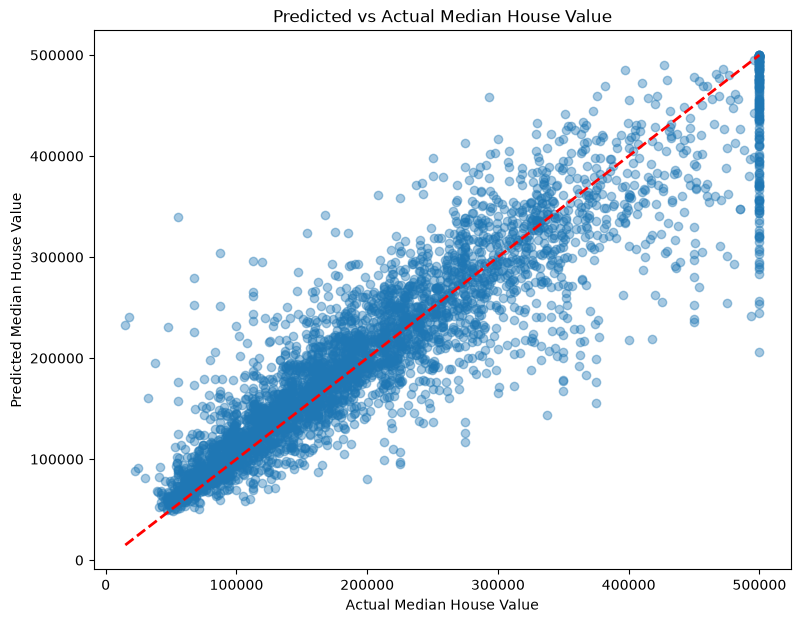

In [13]:
plt.figure(figsize=(9, 7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.4
)

low = min(y_test.min(), y_pred.min())
high = max(y_test.max(), y_pred.max())

plt.plot(
    [low, high],
    [low, high],
    "r--",
    linewidth=2
)

plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Predicted vs Actual Median House Value")
plt.show()


## Q10 — Top-10 feature importances

,Feature,Importance
7,num__median_income,0.443971
9,cat__ocean_proximity_INLAND,0.150790
0,num__longitude,0.114365
1,num__latitude,0.103702
2,num__housing_median_age,0.048971
5,num__population,0.037350
3,num__total_rooms,0.029341
4,num__total_bedrooms,0.026687
6,num__households,0.025297
8,cat__ocean_proximity_<1H OCEAN,0.010878


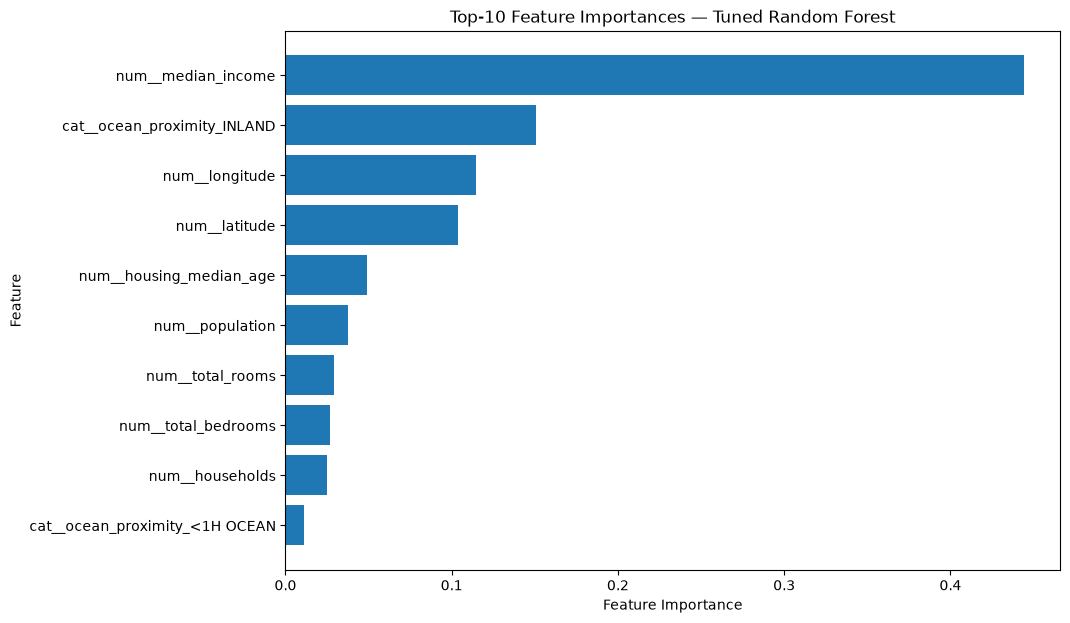

In [14]:
feature_names = best_model.named_steps[
    "preprocessor"
].get_feature_names_out()

importances = best_model.named_steps[
    "model"
].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

top10 = importance_df.head(10)

display(top10)

plt.figure(figsize=(10, 7))

plt.barh(
    top10["Feature"][::-1],
    top10["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top-10 Feature Importances — Tuned Random Forest")
plt.show()


## Final result summary

In [15]:
print("=" * 70)
print("FINAL ASSIGNMENT RESULTS")
print("=" * 70)

print("\nQ1 — Stratified split")
print("Train size:", len(train_set))
print("Test size :", len(test_set))
print("Train income_cat counts:")
print(train_income_counts)
print("Test income_cat counts:")
print(test_income_counts)

print("\nQ2 — Preprocessed training shape")
print(X_train_prepared.shape)

print("\nQ3 — 5-fold CV RMSE")
print(f"Linear Regression : {lin_scores.mean():,.2f} ± {lin_scores.std():,.2f}")
print(f"Decision Tree     : {tree_scores.mean():,.2f} ± {tree_scores.std():,.2f}")
print(f"Random Forest     : {forest_scores.mean():,.2f} ± {forest_scores.std():,.2f}")

print("\nQ4 — Grid search")
print("Best parameters:", grid_search.best_params_)
print(f"Best CV RMSE: {-grid_search.best_score_:,.2f}")

print("\nQ5 — Test set")
print(f"RMSE: {test_rmse:,.2f}")
print(f"MAE : {test_mae:,.2f}")
print(f"R²  : {test_r2:.4f}")

print("\nQ6 — Normal Equation vs sklearn")
print(comparison.to_string(index=False))


FINAL ASSIGNMENT RESULTS

Q1 — Stratified split
Train size: 16512
Test size : 4128
Train income_cat counts:
income_cat
1     657
2    5265
3    5789
4    2911
5    1890
Name: count, dtype: int64
Test income_cat counts:
income_cat
1     165
2    1316
3    1447
4     728
5     472
Name: count, dtype: int64

Q2 — Preprocessed training shape
(16512, 13)

Q3 — 5-fold CV RMSE
Linear Regression : 69,218.40 ± 689.40
Decision Tree     : 70,676.23 ± 1,522.71
Random Forest     : 49,941.18 ± 778.72

Q4 — Grid search
Best parameters: {'model__max_features': 8, 'model__n_estimators': 200}
Best CV RMSE: 49,081.70

Q5 — Test set
RMSE: 46,563.78
MAE : 30,805.89
R²  : 0.8336

Q6 — Normal Equation vs sklearn
         Parameter         NumPy       Sklearn  % Difference
         Intercept -10189.032759 -10189.032759  8.926212e-14
     median_income  43169.190754  43169.190754  5.056354e-14
housing_median_age   1744.134446   1744.134446  3.780578e-13
